In [1]:
import numpy as np 
import pandas as pd 
import os

BASE_PATH = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23'
FAKE_PATHS = ['Face2Face', 'Deepfakes', 'NeuralTextures', 'FaceShifter', 'FaceSwap', 'DeepFakeDetection']
CSV_PATHS = ['csv']
ORIGINAL_PATHS = ['original']

original_video_files = []
fake_video_files = []

labels = {
    'original':0,
    'Face2Face':1,
    'Deepfakes':1,
    'NeuralTextures':1,
    'FaceShifter':1,
    'FaceSwap':1,
    'DeepFakeDetection':1,
}

for fake_path in FAKE_PATHS:
    print(fake_path)
    print(BASE_PATH + fake_path)
    for dirname, _, filenames in os.walk(BASE_PATH + '/' + fake_path):
        print(f"{fake_path}: length: {len(filenames)}")

Face2Face
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23Face2Face
Face2Face: length: 1000
Deepfakes
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23Deepfakes
Deepfakes: length: 1000
NeuralTextures
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23NeuralTextures
NeuralTextures: length: 1000
FaceShifter
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23FaceShifter
FaceShifter: length: 1000
FaceSwap
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23FaceSwap
FaceSwap: length: 1000
DeepFakeDetection
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23DeepFakeDetection
DeepFakeDetection: length: 1000


In [2]:
# Frame Extraction Method
import cv2
import os
def extract_images(video_path, max_frames = 10):
    vid = cv2.VideoCapture(video_path)
    total = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))
    ret_frames = []
    if total==0:
        vid.release()
        return ret_frames
    frame_index = 0
    indices = np.linspace(0, total - 1, num=max_frames, endpoint=True, retstep=False, dtype=int)
    while vid.isOpened():
        ret, frame = vid.read()
        if not ret:
            break
        if frame_index in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ret_frames.append(frame)
        frame_index=frame_index+1
    vid.release()
    return ret_frames

In [3]:
#Actually Getting All the Frames
SAVE_PATH = '/kaggle/working/frames'
os.makedirs(SAVE_PATH, exist_ok=True)
all_frames = []
all_labels = []
all_categories = []

total_existing = sum(
    len(files) for _, _, files in os.walk(SAVE_PATH)
)
if total_existing>100:
    for category, label in labels.items():
        cat_path = os.path.join(SAVE_PATH, category)
        if not os.path.exists(cat_path):
            continue
        for filename in sorted(os.listdir(cat_path)):
            if filename.endswith('.png'):
                filepath = os.path.join(cat_path, filename)
                frame = cv2.imread(filepath)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (224, 224))
                all_frames.append(frame)
                all_labels.append(label)
                all_categories.append(category)
        print(f"{category}: loaded {len(os.listdir(cat_path))} frames")
else:
    for category, label in labels.items():
        save_cat_path = os.path.join(SAVE_PATH, category)
        os.makedirs(save_cat_path, exist_ok=True)
        active_dir = BASE_PATH + '/' + category
        curr_vids = []
        for dirname, _, filenames in os.walk(active_dir):
            for f in filenames:
                if f.endswith(('.mp4', '.avi', '.mov')):
                    curr_vids.append(os.path.join(active_dir, f))
        curr_vids = curr_vids[:100]
        print(f"{category}: found {len(curr_vids)} videos")
        for i, video_path in enumerate(curr_vids):
            if i % 10 == 0:
                print(f"  Processing video {i}/{len(curr_vids)}")
            frames = extract_images(video_path, max_frames=10)
            for j, frame in enumerate(frames):
                frame = cv2.resize(frame, (224, 224))
                save_file = os.path.join(save_cat_path, f'vid{i}_frame{j}.png')
                cv2.imwrite(save_file, frame)
                all_frames.append(frame)
                all_labels.append(label)
                all_categories.append(category)
print(f"\nTotal frames extracted: {len(all_frames)}")
print(f"Total labels: {len(all_labels)}")

original: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Processing video 40/100
  Processing video 50/100
  Processing video 60/100
  Processing video 70/100
  Processing video 80/100
  Processing video 90/100
Face2Face: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Processing video 40/100
  Processing video 50/100
  Processing video 60/100
  Processing video 70/100
  Processing video 80/100
  Processing video 90/100
Deepfakes: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Processing video 40/100
  Processing video 50/100
  Processing video 60/100
  Processing video 70/100
  Processing video 80/100
  Processing video 90/100
NeuralTextures: found 100 videos
  Processing video 0/100
  Processing video 10/100
  Processing video 20/100
  Processing video 30/100
  Pr

In [4]:
#Splitting into Train, Test, Validate Sets
from sklearn.model_selection import train_test_split
all_frames = np.array(all_frames)
all_labels = np.array(all_labels)
all_types = np.array(all_categories)
X_train, X_temp, y_train, y_temp, types_train, types_temp = train_test_split(all_frames, all_labels, all_types, test_size=0.3, random_state=43, stratify=all_labels)
X_val, X_test, y_val, y_test, types_val, types_test = train_test_split(X_temp, y_temp, types_temp, test_size=0.5, random_state=43, stratify=y_temp)
print(f"X_Train length: {len(X_train)}")
print(f"X_val length: {len(X_val)}")
print(f"X_test length: {len(X_test)}")
print(f"Total Length: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Train - Real: {sum(y_train==0)}, Train - Fake: {sum(y_train==1)}")
print(f"Test - Real: {sum(y_test==0)}, Test - Fake: {sum(y_test==1)}")
print(f"Val - Real: {sum(y_val==0)}, Val - Fake: {sum(y_val==1)}")

X_Train length: 4900
X_val length: 1050
X_test length: 1050
Total Length: 7000
Train - Real: 700, Train - Fake: 4200
Test - Real: 150, Test - Fake: 900
Val - Real: 150, Val - Fake: 900


Train manipulation types:
Counter({np.str_('Deepfakes'): 717, np.str_('NeuralTextures'): 706, np.str_('FaceShifter'): 701, np.str_('original'): 700, np.str_('Face2Face'): 698, np.str_('FaceSwap'): 691, np.str_('DeepFakeDetection'): 687})

Val manipulation types:
Counter({np.str_('FaceShifter'): 155, np.str_('FaceSwap'): 155, np.str_('Face2Face'): 153, np.str_('original'): 150, np.str_('Deepfakes'): 149, np.str_('DeepFakeDetection'): 146, np.str_('NeuralTextures'): 142})

Test manipulation types:
Counter({np.str_('DeepFakeDetection'): 167, np.str_('FaceSwap'): 154, np.str_('NeuralTextures'): 152, np.str_('original'): 150, np.str_('Face2Face'): 149, np.str_('FaceShifter'): 144, np.str_('Deepfakes'): 134})


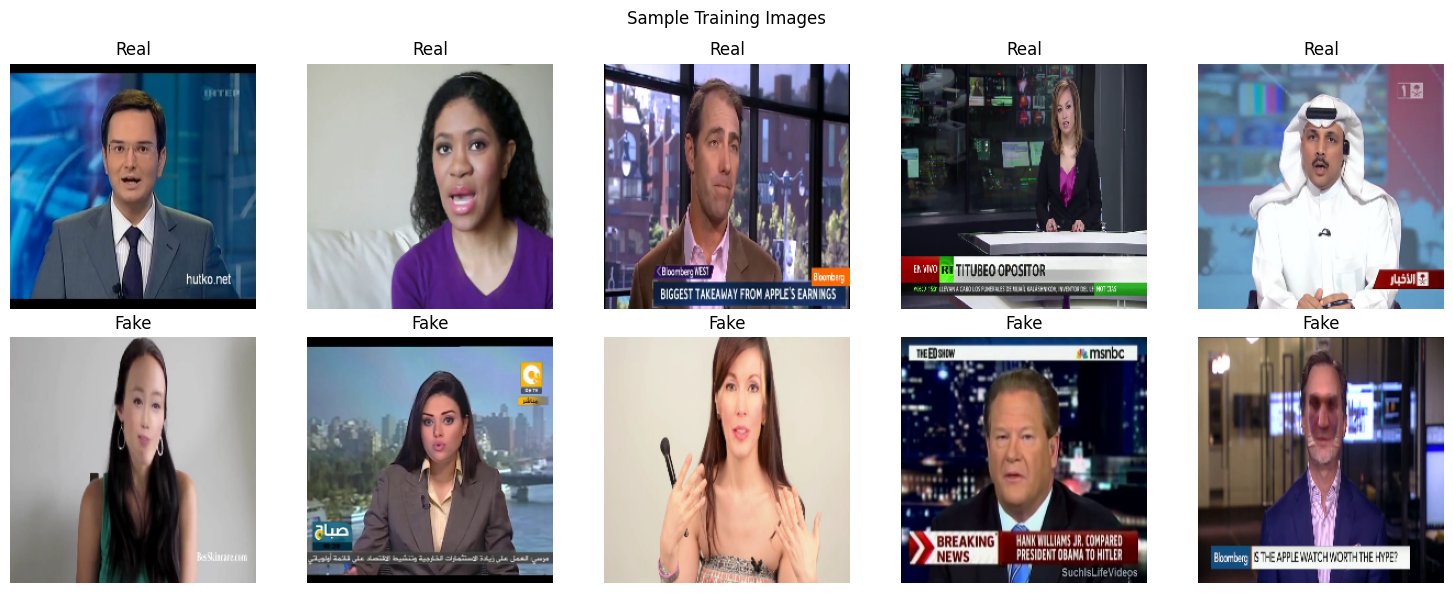

In [5]:
#Verifying Proper Splitting
import matplotlib.pyplot as plt
from collections import Counter

print("Train manipulation types:")
print(Counter(types_train))
print("\nVal manipulation types:")
print(Counter(types_val))
print("\nTest manipulation types:")
print(Counter(types_test))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images')

for i in range(5):
    real_idx = np.where(y_train == 0)[0][i]
    axes[0][i].imshow(X_train[real_idx])
    axes[0][i].set_title('Real')
    axes[0][i].axis('off')
    
    fake_idx = np.where(y_train == 1)[0][i]
    axes[1][i].imshow(X_train[fake_idx])
    axes[1][i].set_title(f'Fake')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
#Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class DeepfakeDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, image_idx):
        img = self.images[image_idx]
        if isinstance(img, str):
            img = Image.open(img).convert('RGB')
        else:
            img = Image.fromarray(img.astype(np.uint8))
        label = self.labels[image_idx]
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                        [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                        [0.229, 0.224, 0.225])
])

In [24]:
train_dataset = DeepfakeDataset(X_train, y_train, train_transform)
test_dataset = DeepfakeDataset(X_test, y_test, test_transform)
validate_dataset = DeepfakeDataset(X_val, y_val, test_transform)

train_dataloader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, num_workers=2, shuffle=False)
validate_dataloader = DataLoader(validate_dataset, batch_size=32, num_workers=2, shuffle=False)

print(f"Train batches: {len(trainLoader)}")
print(f"Val batches:   {len(validateLoader)}")
print(f"Test batches:  {len(testLoader)}")

images, labels_batch = next(iter(trainLoader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels_batch.shape}")
print(f"Label values: {labels_batch[:5]}")

Train batches: 154
Val batches:   33
Test batches:  33
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label values: tensor([0, 0, 0, 1, 1])


In [38]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
#Base Model Training ResNet18
def get_resnet_baseline():
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    layers_to_freeze = ['layer1', 'layer2']
    for name, param in model.named_parameters():
        if any(layer in name for layer in layers_to_freeze): 
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #Train using GPU if available else CPU
print(f"Using device: {device}")

baseline_model = get_resnet_baseline()
baseline_model = baseline_model.to(device)
print("Baseline ResNet18 ready")

Using device: cuda
Baseline ResNet18 ready


In [39]:
#Training Loop Code
import torch.nn as nn
import torchvision.models as models
def train_model(model, train_dataloader, validate_dataloader, epochs=10, learning_rate=1e-4, model_name='model'):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4
    )
    #Fixing Class Imbalance by penalizing Fake Predictions more
    num_real = sum(y_train == 0)
    num_fake = sum(y_train == 1)
    total = len(y_train)

    weight_real = total / (2 * num_real)
    weight_fake = total / (2 * num_fake)
    class_weights = torch.FloatTensor([weight_real, weight_fake]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    history={'train_loss':[],'validate_loss':[], 'train_accuracy':[], 'validate_accuracy':[]}
    best_validate_accuracy = 0
    for epoch in range(epochs):
        #Training
        model.train()
        train_loss, train_correct = 0,0
        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
        #Validation
        model.eval()
        validate_loss, validate_correct = 0,0
        with torch.no_grad():
            for images, labels in validate_dataloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                validate_loss += loss.item()
                validate_correct += (outputs.argmax(1) == labels).sum().item()
        scheduler.step()

        train_accuracy = train_correct / len(train_dataloader.dataset)
        validate_accuracy = validate_correct / len(validate_dataloader.dataset)
        history['train_loss'].append(train_loss/len(train_dataloader))
        history['validate_loss'].append(validate_loss/len(validate_dataloader))
        history['train_accuracy'].append(train_accuracy)
        history['validate_accuracy'].append(validate_accuracy)
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Accuracy: {train_accuracy:.4f} | "
              f"Validate Accuracy: {validate_accuracy:.4f} | " 
              f"Train Loss: {train_loss/len(train_dataloader):.4f}")

        if validate_accuracy > best_validate_accuracy:
            best_validate_accuracy = validate_accuracy
            torch.save(model.state_dict(), f"/kaggle/working/{model_name}_best.pth")
            print(f"New Best Model saved ({validate_accuracy:.4f})")
    return model, history

In [40]:
baseline_model, baseline_history=train_model(
    baseline_model,
    train_dataloader,
    validate_dataloader,
    epochs=10,
    learning_rate=1e-4,
    model_name='resnet18_baseline'
)

Epoch 1/10 | Train Accuracy: 0.8522 | Validate Accuracy: 0.9638 | Train Loss: 0.3061
New Best Model saved (0.9638)
Epoch 2/10 | Train Accuracy: 0.9514 | Validate Accuracy: 0.9657 | Train Loss: 0.1173
New Best Model saved (0.9657)
Epoch 3/10 | Train Accuracy: 0.9624 | Validate Accuracy: 0.9495 | Train Loss: 0.0837
Epoch 4/10 | Train Accuracy: 0.9584 | Validate Accuracy: 0.9657 | Train Loss: 0.0733
Epoch 5/10 | Train Accuracy: 0.9631 | Validate Accuracy: 0.9705 | Train Loss: 0.0609
New Best Model saved (0.9705)
Epoch 6/10 | Train Accuracy: 0.9651 | Validate Accuracy: 0.9714 | Train Loss: 0.0725
New Best Model saved (0.9714)
Epoch 7/10 | Train Accuracy: 0.9665 | Validate Accuracy: 0.9667 | Train Loss: 0.0604
Epoch 8/10 | Train Accuracy: 0.9722 | Validate Accuracy: 0.9686 | Train Loss: 0.0479
Epoch 9/10 | Train Accuracy: 0.9747 | Validate Accuracy: 0.9676 | Train Loss: 0.0482
Epoch 10/10 | Train Accuracy: 0.9763 | Validate Accuracy: 0.9648 | Train Loss: 0.0466



 ---------ResNet18 Baseline Results---------
              precision    recall  f1-score   support

        Real       0.79      0.97      0.87       150
        Fake       1.00      0.96      0.98       900

    accuracy                           0.96      1050
   macro avg       0.89      0.97      0.92      1050
weighted avg       0.97      0.96      0.96      1050

ROC-AUC: 0.9974


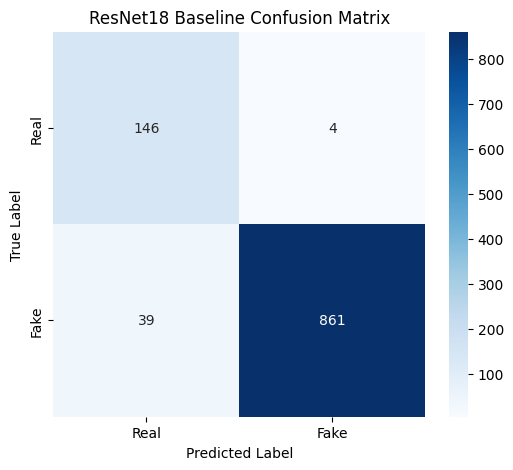

In [42]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
import seaborn as sns

def evaluate_model(model, test_dataloader, model_name='model'):
    model.eval() #Set model mode to Eval
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            predictions = outputs.argmax(1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    print(f"\n ---------{model_name} Results---------")
    print(classification_report(all_labels, all_predictions, target_names=['Real', 'Fake']))
    print(f"ROC-AUC: {roc_auc_score(all_labels, all_probabilities):.4f}")

    #Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.savefig(f"/kaggle/working/{model_name}_confusion_matrix.png")
    plt.show()

    return all_predictions, all_labels, all_probabilities

baseline_predictions, baseline_labels, baseline_probabilities = evaluate_model(baseline_model, test_dataloader, 'ResNet18 Baseline')
